# YOLO “step-by-step”

Obiettivo: capire **i passi concettuali** di YOLO

1. **Input & preprocessing** (resize/letterbox, normalizzazione)
2. **Forward**: output del modello (box + objectness + class scores)
3. **Confidence filtering**
4. **Non-Maximum Suppression (NMS)**: perché serve e come funziona
5. **Disegno delle box finali**
6. Collegamento ai concetti: **grid / anchor / stride / head**

> Nota: useremo un modello YOLO pre-addestrato via libreria `ultralytics` (YOLOv8),  
> ma poi **ispezioniamo gli output** e rifacciamo a mano alcune parti (threshold + NMS).

## 0) Installazione (first time only)

In [ ]:
# Se non hai ultralytics installato (tipico su Colab):
# !pip install ultralytics

## 1) Import e funzioni utili (IoU, NMS, plotting)

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def show_image_with_boxes(pil_img, boxes_xyxy, labels=None, scores=None, title=None):
    """Disegna box (x1,y1,x2,y2) su immagine."""
    plt.figure(figsize=(8,8))
    plt.imshow(pil_img)
    ax = plt.gca()
    for i, box in enumerate(boxes_xyxy):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1,y1), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        text = None
        if labels is not None:
            text = str(labels[i])
        if scores is not None:
            text = (text + ' ' if text else '') + f"{scores[i]:.2f}"
        if text:
            ax.text(x1, y1, text, color='yellow', fontsize=10,
                    bbox=dict(facecolor='red', alpha=0.5, pad=2))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def box_iou_xyxy(a, b):
    """IoU tra due box in formato xyxy (numpy)."""
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)

    union = area_a + area_b - inter_area + 1e-9
    return inter_area / union

def nms_xyxy(boxes, scores, iou_threshold=0.5):
    """NMS semplice (numpy): tiene box con score alto e rimuove quelle che si sovrappongono troppo."""
    idxs = np.argsort(scores)[::-1]  # decrescente
    keep = []
    while len(idxs) > 0:
        i = idxs[0]
        keep.append(i)
        rest = idxs[1:]
        new_rest = []
        for j in rest:
            if box_iou_xyxy(boxes[i], boxes[j]) < iou_threshold:
                new_rest.append(j)
        idxs = np.array(new_rest, dtype=int)
    return keep

## 2) Caricamento di un modello YOLO e di un’immagine

In [2]:
from ultralytics import YOLO
import requests
from io import BytesIO

# Modello piccolo e veloce, buono per didattica
yolo = YOLO("yolov8n.pt")

# Immagine di esempio (puoi sostituire con una tua immagine locale)
url = "https://ultralytics.com/images/bus.jpg"
pil_img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
pil_img.size, pil_img

((810, 1080), <PIL.Image.Image image mode=RGB size=810x1080>)

## 3) Step 1 — Preprocessing (concetto di letterbox)

YOLO tipicamente:
- ridimensiona l’immagine alla dimensione del modello (es. 640×640)
- mantiene le proporzioni aggiungendo **padding** (letterbox)
- normalizza i pixel

La libreria Ultralytics fa questi passi internamente.
Qui esplicitiamo:
- dimensione originale
- dimensione “in input al modello” (in genere 640)

In [3]:
results = yolo.predict(pil_img, imgsz=640, conf=0.25, verbose=False)
res = results[0]

print("Dimensione originale:", pil_img.size)
print("Dimensione input usata dal modello (imgsz):", 640)

Dimensione originale: (810, 1080)
Dimensione input usata dal modello (imgsz): 640


## 4) Step 2 — Output del modello: box, score, classe

Ultralytics restituisce in output un oggetto `Boxes` con:
- `xyxy`: coordinate box (x1,y1,x2,y2) in pixel sull’immagine originale
- `conf`: confidenza
- `cls`: indice classe

Usando `predict`, si ottiene un output che include già il **post-processing** (include NMS)  

Per capire i passi, noi faremo:
1) visualizzare le box finali (dopo NMS)  
2) poi simulare threshold + NMS “a mano” su un set di box (didattico)

Numero box finali: 6
Prime 5 box: [[     22.871      231.28         805      756.84]
 [      48.55      398.55      245.35       902.7]
 [     669.47      392.19      809.72      877.04]
 [     221.52       405.8      344.97      857.54]
 [          0      550.53      63.007      873.44]]
Prime 5 conf: [    0.87345     0.86569     0.85284     0.82522     0.26111]
Prime 5 cls: [5 0 0 0 0]


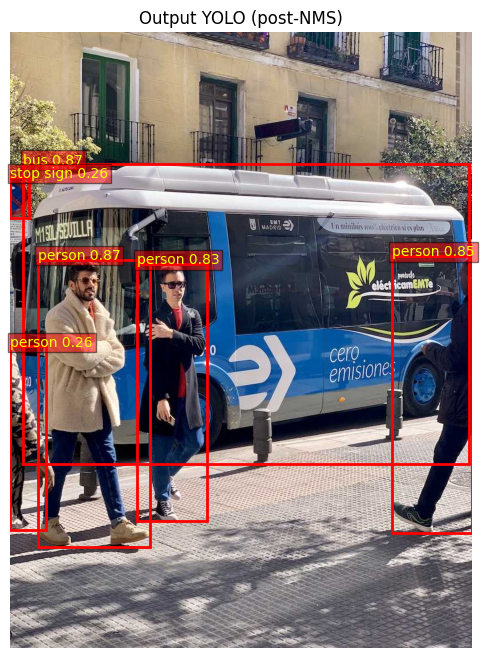

In [4]:
# Box finali (già filtrate e NMS applicata dal modello)
boxes_xyxy = res.boxes.xyxy.cpu().numpy()
scores = res.boxes.conf.cpu().numpy()
clss = res.boxes.cls.cpu().numpy().astype(int)

print("Numero box finali:", len(boxes_xyxy))
print("Prime 5 box:", boxes_xyxy[:5])
print("Prime 5 conf:", scores[:5])
print("Prime 5 cls:", clss[:5])

# Nomi classi COCO
names = res.names
labels = [names[c] for c in clss]

show_image_with_boxes(pil_img, boxes_xyxy, labels=labels, scores=scores, title="Output YOLO (post-NMS)")

## 5) Step 3 — Confidence threshold (filtrare le box)

Prima di NMS, un detector produce moltissime box candidate.
Un primo filtro tipico è:

- tenere solo quelle con `score >= conf_threshold`

Qui facciamo un esempio **a partire dalle box finali** (che sono già pulite),
solo per mostrare l’effetto del threshold.

thr=0.25 -> 6 box


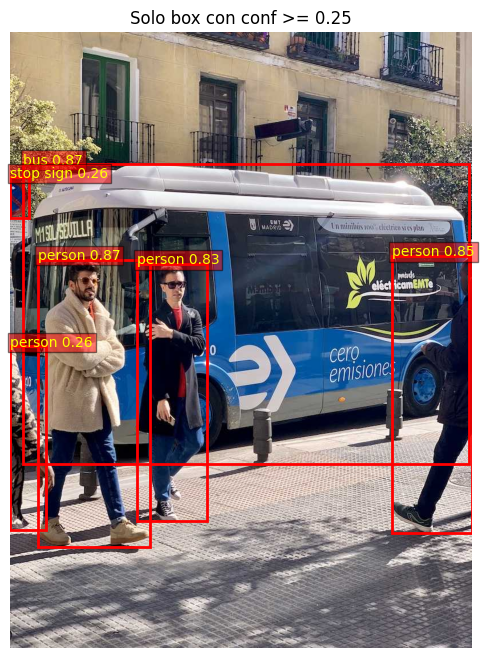

thr=0.50 -> 4 box


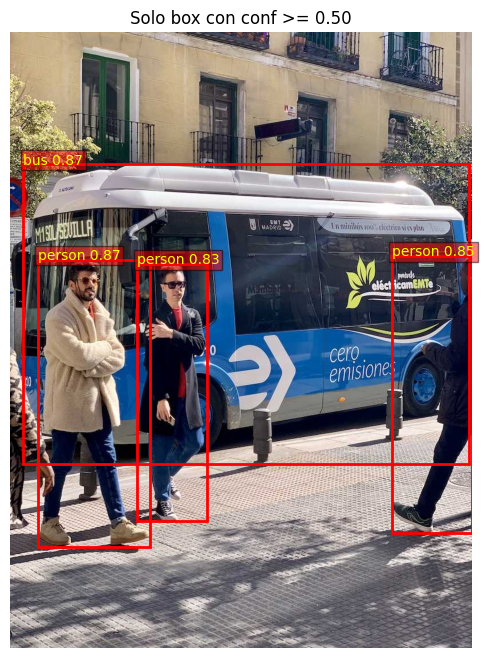

thr=0.75 -> 4 box


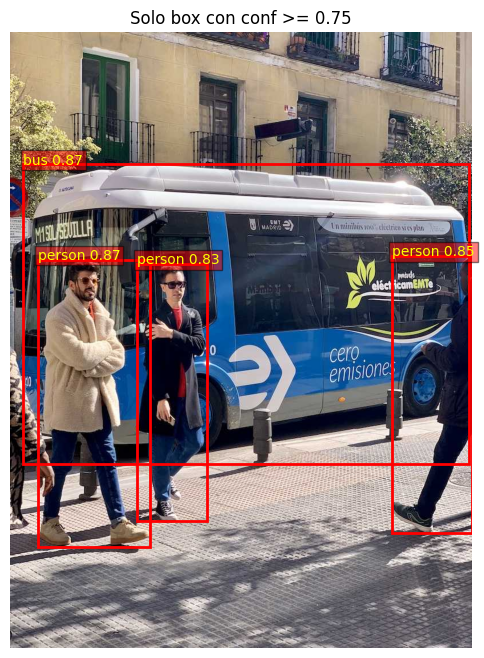

In [5]:
def filter_by_conf(boxes, scores, labels, conf_threshold):
    keep = scores >= conf_threshold
    return boxes[keep], scores[keep], [lab for lab, k in zip(labels, keep) if k]

for thr in [0.25, 0.5, 0.75]:
    b, s, l = filter_by_conf(boxes_xyxy, scores, labels, thr)
    print(f"thr={thr:.2f} -> {len(b)} box")
    show_image_with_boxes(pil_img, b, labels=l, scores=s, title=f"Solo box con conf >= {thr:.2f}")

## 6) Step 4 — NMS con un esempio sintetico

La **Non-Maximum Suppression** serve perché più box “simili” (sovrapposte) possono descrivere lo stesso oggetto.

Idea:
1. ordina box per score (dal più alto)
2. prendi la migliore e **rimuovi** quelle troppo sovrapposte (IoU alta)
3. ripeti

Facciamo un esempio con box “finte” per capire IoU e NMS.

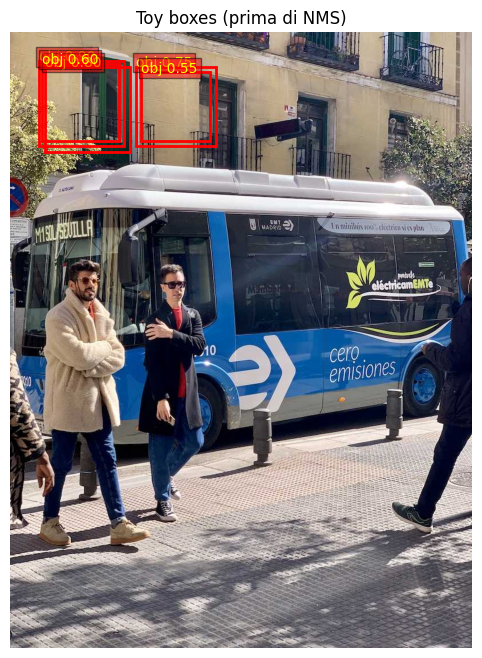

IoU(A,B) = 0.7716535433070563
IoU(C,E) = 0.7346938775509829
Indici tenuti da NMS: [0, 2]


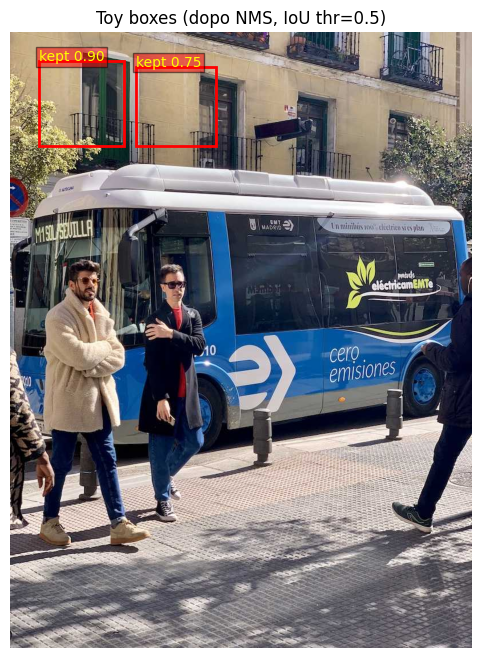

In [6]:
# Esempio giocattolo: 5 box, alcune sovrapposte
toy_boxes = np.array([
    [50, 50, 200, 200],     # box A
    [60, 60, 210, 210],     # box B (molto simile ad A)
    [220, 60, 360, 200],    # box C (separata)
    [55, 55, 190, 190],     # box D (simile ad A)
    [230, 70, 350, 190],    # box E (simile a C)
], dtype=float)

toy_scores = np.array([0.90, 0.80, 0.75, 0.60, 0.55])
toy_labels = ["obj"] * len(toy_boxes)

# Mostriamo le box tutte insieme
show_image_with_boxes(pil_img, toy_boxes, labels=toy_labels, scores=toy_scores, title="Toy boxes (prima di NMS)")

# IoU tra A e B
print("IoU(A,B) =", box_iou_xyxy(toy_boxes[0], toy_boxes[1]))
print("IoU(C,E) =", box_iou_xyxy(toy_boxes[2], toy_boxes[4]))

keep = nms_xyxy(toy_boxes, toy_scores, iou_threshold=0.5)
print("Indici tenuti da NMS:", keep)

show_image_with_boxes(pil_img, toy_boxes[keep], labels=["kept"]*len(keep), scores=toy_scores[keep],
                      title="Toy boxes (dopo NMS, IoU thr=0.5)")